In [8]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
dsetname = "adult"
dsetnamex = "Adult"
d = 14

######
graphsx = np.load("../graphs/"+dsetname+"_thresh_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/adult_thresh_graphsummary.npy")
randomgraphsinfo


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),4.0,328,48,12,36,12.695122,3.719512,8.975610,86.750000,4.561858,1.525352,3.036506,6,51,35,0,0
1,Adult (14),4.5,328,49,12,37,19.545732,5.262195,14.283537,130.836735,9.621176,2.785671,6.835505,2,33,21,0,1
2,Adult (14),5.0,328,49,12,37,27.003049,6.871951,20.131098,180.755102,17.002780,4.458725,12.544055,2,20,9,0,2
3,Adult (14),5.5,328,49,12,37,33.466463,8.344512,25.121951,224.020408,24.895193,6.197862,18.697331,0,9,6,0,3
4,Adult (14),6.0,328,49,12,37,38.951220,9.612805,29.338415,260.734694,32.537136,7.907118,24.630018,0,6,2,0,4
5,Adult (14),6.5,328,49,12,37,42.829268,10.585366,32.243902,286.693878,38.457224,9.440442,29.016782,1,4,0,0,5
6,Adult (14),7.0,328,49,12,37,45.698171,11.286585,34.411585,305.897959,43.116991,10.646770,32.470221,0,2,0,0,6
7,Adult (14),7.5,328,49,12,37,47.350610,11.695122,35.655488,316.959184,45.946297,11.404863,34.541434,0,0,0,0,7
8,Adult (14),8.0,328,49,12,37,48.256098,11.887195,36.368902,323.020408,47.579007,11.776535,35.802473,0,0,0,2,8
9,Adult (14),8.5,328,49,12,37,48.698171,11.960366,36.737805,325.979592,48.411520,11.920955,36.490565,0,0,0,6,9


## Learning

In [4]:
summary_dfx = scripts.algorithms.learn_greedy(datagraphs=graphsx, 
                                               dim=d,
                                               savedname=dsetname,
                                               thresh=True)

summary_dfx.to_csv("./ls_results/"+dsetname+"_learn_results_thresh.csv", index=False)
summary_dfx.head(10)

,K,dataset,graphid,r,n,m,tr_utility,ts_utility,tr_size,ts_size,...,ts_only-Ns,tr_empty_adj,ts_empty_adj,tr_perf1,ts_perf1,tr_perf2,ts_perf2,tr_perf3,ts_perf3,greedyTime
0,1,adult (14),0,4.0,328,48,141.084813,61.090724,229.0,99.0,...,15.41,24.86,10.14,83.70198,83.15519,61.60909,61.70778,83.29160,82.71902,0.138184
1,2,adult (14),0,4.0,328,48,161.159518,69.760933,229.0,99.0,...,15.41,24.86,10.14,95.61327,94.96454,70.37531,70.46562,95.50232,94.83284,0.268509
2,3,adult (14),0,4.0,328,48,164.319486,70.791843,229.0,99.0,...,15.41,24.86,10.14,97.48868,96.36971,71.75520,71.50694,97.42533,96.27555,0.396326
3,4,adult (14),0,4.0,328,48,166.127321,71.378925,229.0,99.0,...,15.41,24.86,10.14,98.56160,97.17266,72.54465,72.09996,98.52549,97.09784,0.527057
4,5,adult (14),0,4.0,328,48,167.353349,72.065730,229.0,99.0,...,15.41,24.86,10.14,99.28943,98.10744,73.08003,72.79374,99.27150,98.05865,0.651112
5,1,adult (14),1,4.5,328,49,164.783051,71.046927,229.0,99.0,...,9.73,15.02,5.98,86.40379,85.29471,71.95767,71.76457,86.30312,85.18734,0.193560
6,2,adult (14),1,4.5,328,49,183.346690,79.336569,229.0,99.0,...,9.73,15.02,5.98,96.13785,95.24907,80.06403,80.13798,96.10943,95.21524,0.381578
7,3,adult (14),1,4.5,328,49,186.935243,81.145998,229.0,99.0,...,9.73,15.02,5.98,98.01990,97.41582,81.63114,81.96569,98.00533,97.39801,0.566410
8,4,adult (14),1,4.5,328,49,189.220156,82.245763,229.0,99.0,...,9.73,15.02,5.98,99.21834,98.73939,82.62892,83.07653,99.21257,98.73172,0.748179
9,5,adult (14),1,4.5,328,49,190.314571,82.891333,229.0,99.0,...,9.73,15.02,5.98,99.79260,99.51849,83.10672,83.72858,99.79106,99.51536,0.928319


## Plots

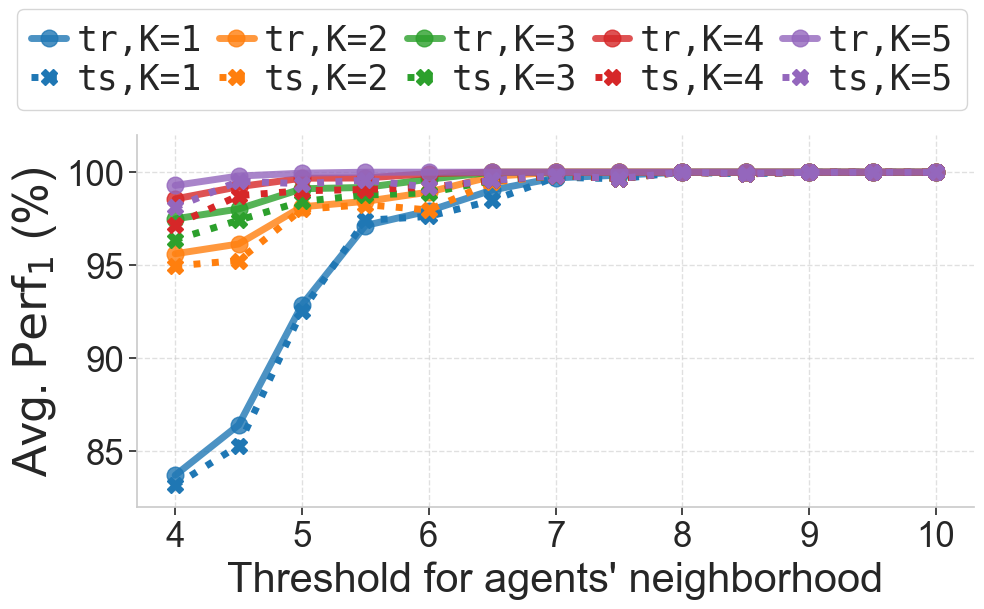

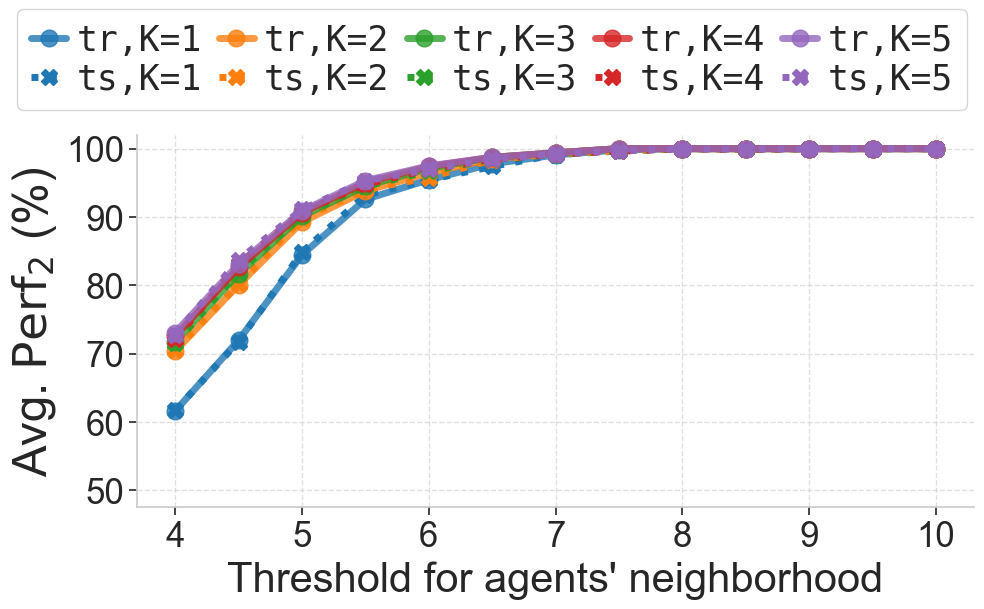

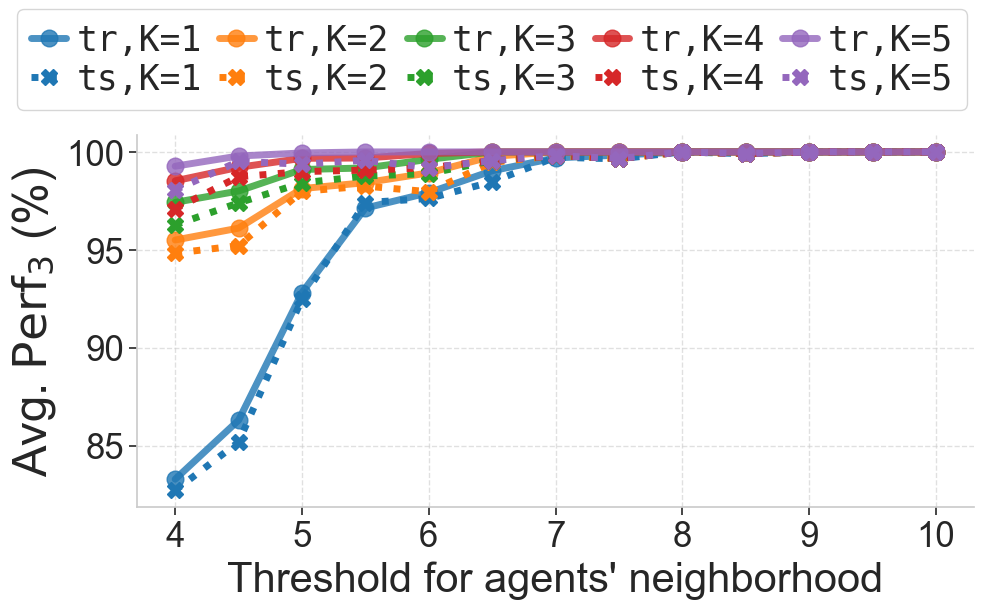

In [9]:
######### exclude: no neighbors and exclusively neg neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=True, 
                  perfv="perf1", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_thresh_perf1.pdf")

######### exclude: none
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=True, 
                  perfv="perf2", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_thresh_perf2.pdf")

######### exclude: no neighbors and exclusively neg/pos neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=True, 
                  perfv="perf3", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_thresh_perf3.pdf")

